## Main Quantitative Pipeline

tbd: deconvolution of the whole 3D image 

This pipieline is used for deconvolution: 

Steps: 
1. Deconvolution

2. Denoising 
3. Background correction

4. Segmentation
5. Quantification 

In [1]:
# imports
import h5py
from pathlib import Path
BASE_DIR = Path.cwd().parent
import stackview
from skimage import (exposure, feature, filters, io, measure,
                      morphology, restoration, segmentation, transform,
                      util) #good for all my deblurring approaches
from napari_simpleitk_image_processing import richardson_lucy_deconvolution # deconvolution
import numpy as np
from skimage.transform import resize
import numpy as np
import matplotlib.pyplot as plt
# make binary image
import cv2 

from pathlib import Path
import sys
project_root = Path().resolve().parent
sys.path.append(str(project_root))
# python files
import src.preprocessing as preproc


#### Specify Paths

In [2]:
full_image_path = Path(BASE_DIR/'data/corrected_images')

In [3]:
# load connexin image 
full_image = True # if False not Zero Padding happens

# image_path = 'seperate_planes/small_region/cnx_(300, 500, 1000).tiff' # small 3D region 
# plane = 54

# image_path = 'corrected_images/cnx43.tif' # full image

# image_path = 'seperate_planes/small_region/cnx_(237, 500, 1000).tiff' # latest test plane 16.04. 
cnx_img = io.imread(Path(full_image_path/'cnx43.tif')) #full image 
psf_path = 'PSF_488nm_cnx.h5'
psf_name = 'PSF_488'

# load cell image
# image_path = 'seperate_planes/small_region/trpn_(300, 500, 1000).tiff'
# image_path = 'corrected_images/cTnT.tif'
# psf_path = 'PSF_561nm_trop.h5'
# psf_name = 'PSF_561'

# load nuclei image
# image_path = 'seperate_planes/small_region/nuclei_(300, 500, 1000).tiff'
# image_path = 'corrected_images/cTnT.tif'
# psf_path = 'PSF_638nm_nuclei.h5'
# psf_name = 'PSF_638'

In [4]:
# #save test plane
x_1 = 500
x_2 = 1000
y_1 = 500
y_2 = 1000
z_1 = 200
z_2 = 300
# io.imsave(Path(BASE_DIR/'data'/'seperate_planes'/'small_region'/'test_original_cnx_254_500_1000.tiff'), cnx_img[254, y_1:y_2, x_1:x_2])


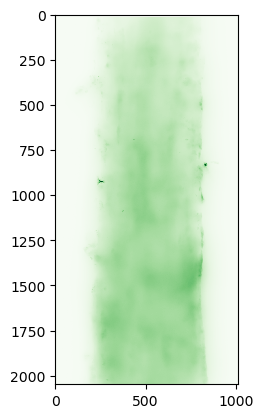

In [5]:
# show image 
stackview.imshow(cnx_img, axes = True, colormap="Greens")

### 1. Deconvolution

method: 
- use experimental PSF 

resource: 
https://haesleinhuepf.github.io/BioImageAnalysisNotebooks/18a_deconvolution/introduction_deconvolution.html

- find the brightest slice 
- shift the PSF so that brightest slice is in center
- pad with zero slices until we reach target slice

In [6]:
# open the psf file 
with h5py.File(BASE_DIR/'data/experimental_PSF'/psf_path, "r") as f:
    psf = f[f'{psf_name}/ImageData/Image'][:]
    psf_info = f[f'{psf_name}/ImageData/Image']
    # f.visit(print) # show all keys

    # find out what axis corresponds the which scale: 
    print("shape:", psf_info.shape)
    print("number of dims:", len(psf_info.dims))

    for i, dim in enumerate(psf_info.dims):
        print("axis", i, "number of attached scales:", len(dim))

shape: (1, 1, 192, 40, 40)
number of dims: 5
axis 0 number of attached scales: 0
axis 1 number of attached scales: 1
axis 2 number of attached scales: 1
axis 3 number of attached scales: 1
axis 4 number of attached scales: 1


In [6]:
stackview.imshow(psf[0,0], axes = True )

NameError: name 'psf' is not defined

In [42]:
print(psf.shape) # 1,1,z,y,x
print(psf[0,0].shape) #without the first 2 dimensions

psf_red = psf[0,0] #reduced psf

(1, 1, 192, 40, 40)
(192, 40, 40)


##### find the brightest slice

In [43]:
brightest_slice = preproc.brightest_slice(psf_red)
print("The brightest slice index:", brightest_slice)

The brightest slice index: 80


##### center the PSF

In [44]:
psf_centered = preproc.center_psf(psf_red, brightest_slice)

center was shifted by:  16


##### normalize psf

In [45]:
psf_normalized = preproc.normalize_psf(psf_centered)
print("normalized sum should be 1: ", psf_normalized.sum())

normalized sum should be 1:  1.0


##### pad with zeros

In [46]:
target_z = cnx_img.shape[0] # tbd don't hardcode: cnx_image.shape[0]
print("target z dimension:", target_z)

target z dimension: 101


In [47]:
if full_image == True:
    psf_padded = preproc.add_zero_padding(psf_normalized, target_z)
    print("New PSF shape:", psf_padded.shape)
else: 
    psf_padded = psf_normalized

ValueError: index can't contain negative values

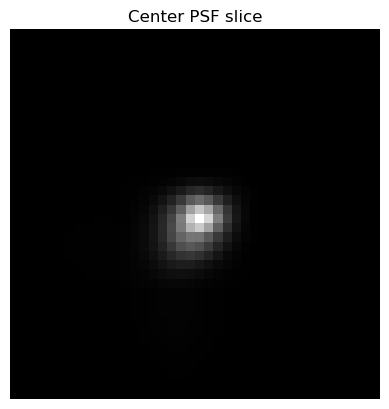

In [17]:
stackview.imshow(psf_padded[target_z//2], colormap='gray', title="Center PSF slice")

In [53]:
# save new PSF with buffer layer 
# io.imsave(Path(BASE_DIR/'data'/'seperate_planes'/'small_region'/f"{psf_name}_padded.tiff"), psf_normalized[195:326,:,:])

### Go here to load the PSF

In [4]:
psf_padded = io.imread(Path(BASE_DIR/'data'/'seperate_planes'/'small_region'/f"{psf_name}_padded.tiff"))

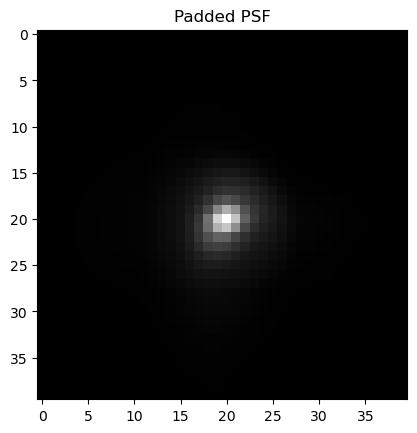

In [5]:
stackview.imshow(psf_padded, axes = True, colormap='gray', title="Padded PSF")

In [24]:
# # Suppose psf.shape = (510, H, W)
# # Compute the "spread" of each layer as the standard deviation of the intensity
# psf_spread = np.zeros(psf_red.shape[0])

# for i in range(psf_red.shape[0]):
#     layer = psf_red[i]
#     # Flatten spatial dimensions and compute std as a measure of spread
#     psf_spread[i] = np.sqrt(np.sum(layer * ((np.arange(layer.shape[0])[:, None] - layer.shape[0]//2)**2 +
#                                              (np.arange(layer.shape[1])[None, :] - layer.shape[1]//2)**2)) /
#                             np.sum(layer))

# # Plot spread vs layer index
# plt.figure(figsize=(10, 5))
# plt.plot(psf_spread, label='PSF spread per layer')
# plt.xlabel('Spectral Layer')
# plt.ylabel('Effective Spread (pixels)')
# plt.title('PSF Spread Across Spectral Layers')
# plt.grid(True)
# plt.legend()
# plt.show()


max value:  0.007673541
max value index:  75


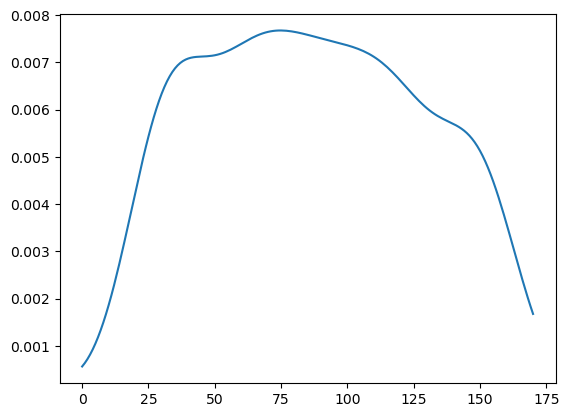

In [8]:
intensity_array = psf_padded.sum(axis=(1,2))
plt.plot(intensity_array)
max_value = max(psf_padded.sum(axis=(1,2)))
print("max value: ", max_value)
print("max value index: ", list(intensity_array).index(max_value))   # the centering shifted the center index only by 16 steps

#### Richardson-Lucy Deconvolution

In [6]:
# fig, axs = plt.subplots(1, 5, figsize=(20,20)) -> this was just for testing 

# stackview.imshow(cnx_img, plot=axs[0], colormap="Greens", min_display_intensity=0, max_display_intensity=40000)
# axs[0].set_title("original")

# # stackview.imshow(convolved, plot=axs[0, 1])
# # axs[0,1].set_title("convolved")

# for i, number_of_iterations in enumerate([10, 20, 40, 80]):

#     deconvolved = richardson_lucy_deconvolution(cnx_img, psf_padded[54], number_of_iterations)

#     axis = axs[i+1]
#     stackview.imshow(deconvolved, plot=axis, colormap="Greens", min_display_intensity=0, max_display_intensity=40000)
    
#     axis.set_title("deconvolved for " + str(number_of_iterations) + " iterations")

In [8]:
deconvolved = richardson_lucy_deconvolution(cnx_img, psf_padded[:], 5) # 5 iterations take 3 min

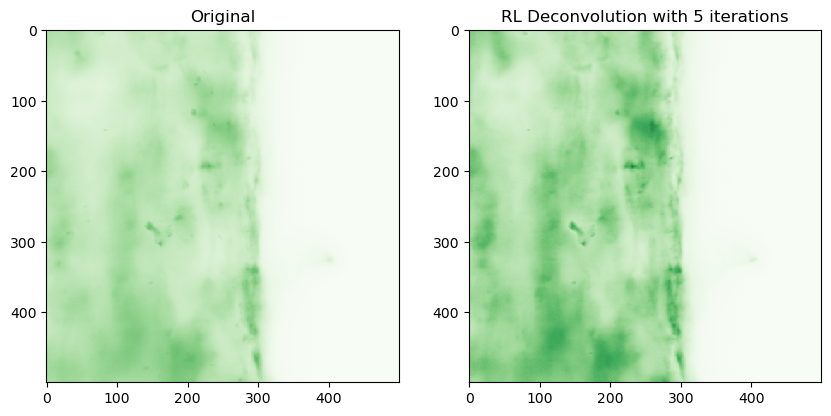

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(10,10))
stackview.imshow(cnx_img, plot=axs[0], axes = True, colormap='Greens', title="Original", max_display_intensity=40000)
stackview.imshow(deconvolved, plot=axs[1], axes = True, colormap='Greens', title="RL Deconvolution with 5 iterations", max_display_intensity=40000)


Analysis: The background is still quite blurry

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(20,20))

stackview.imshow(cnx_img, plot=axs[0],  min_display_intensity=0, max_display_intensity=40000)
axs[0].set_title("original")

# stackview.imshow(convolved, plot=axs[0, 1])
# axs[0,1].set_title("convolved")

for i, number_of_iterations in enumerate([8, 10, 20]):

    deconvolved = richardson_lucy_deconvolution(cnx_img, psf_padded, number_of_iterations) # figured that 8-10 iterations are good for the test plane

    axis = axs[i+1]
    stackview.imshow(deconvolved, plot=axis, min_display_intensity=0, max_display_intensity=40000)
    
    axis.set_title("deconvolved for " + str(number_of_iterations) + " iterations")

: 

## Option 2 Preprocessing + Post Processing

##### Pre-processing with different backgroud substraction methods: Rolling Ball, Gaussian Blur, Top-Hat, Difference of Gaussian (DoG=), Difference form Median

The size of connexin-43 plaques ranges between  $0.5 \mu m$ to $2.0 \mu m$ in diameter
- Rolling Ball: Calculation: If your resolution is $0.5 \mu m/pixel$, a radius of 5–6 pixels is a good starting point.
- Median Filter: Recommended size: A $3 \times 3$ or $5 \times 5$ pixel window.Anything larger will start to merge neighboring Connexin dots, making it look like one large, fake structure.

In [10]:
# background substraction using rolling ball method
from skimage.restoration import rolling_ball 
# from skimage.filters import gaussian
# from skimage.filters import difference_of_gaussians
from skimage.morphology import white_tophat
from skimage.filters import median, gaussian

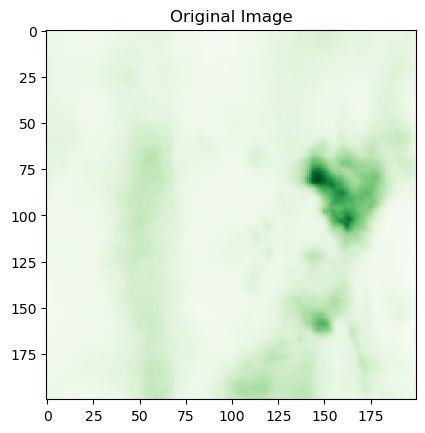

In [11]:
stackview.imshow(cnx_img[10][200:400, :200], axes = True, colormap='Greens', title="Original Image")

In [12]:
# compute the background using the rolling ball method and subtract it from the original image
background_rolling = rolling_ball(cnx_img[10][200:400, :200], radius=10) #radius is the region looked at when determining what is background. It should be bigger than a connexin plaque so 30-50px 2.9 s per slide -> 290s per 100 slide = ca. 5 min for 100 slides
background_subtracted_rolling = cnx_img[10][200:400, :200] - background_rolling

In [13]:
# background substraction using difference of gaussians
background_tophat = white_tophat(cnx_img[10][200:400, :200])  # tbd which sigma values are good for connexin plaques? 1 and 40 are just a guess
background_subtracted_tophat = cnx_img[10][200:400, :200] - background_tophat

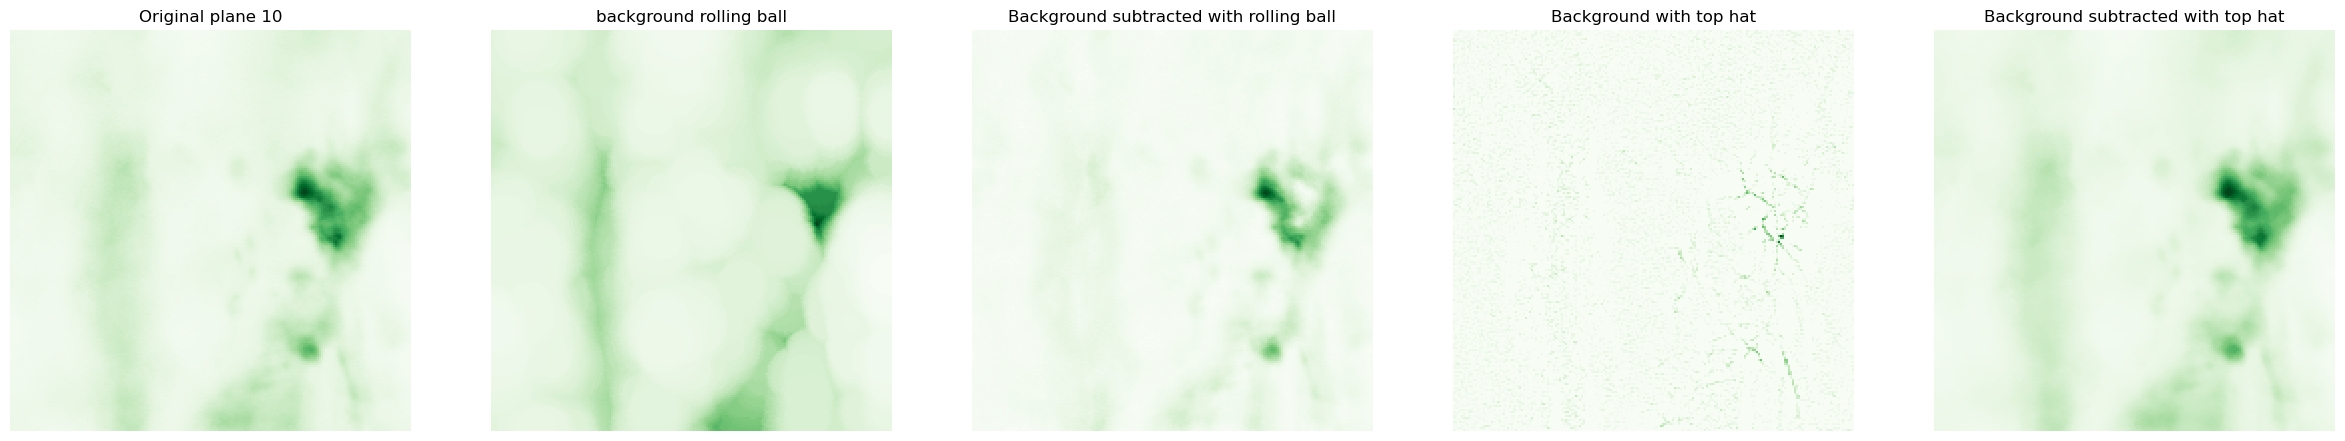

In [117]:
fig, axs = plt.subplots(1, 5, figsize=(30,20))

stackview.imshow(cnx_img[10][200:400, :200], plot=axs[0], colormap="Greens",title = "Original plane 10")
stackview.imshow(background_rolling,plot = axs[1], title = "background rolling ball", colormap='Greens')
stackview.imshow(background_subtracted_rolling, plot = axs[2], colormap='Greens', title="Background subtracted with rolling ball")
stackview.imshow(background_tophat , plot = axs[3],colormap='Greens', title="Background with top hat")
stackview.imshow(background_subtracted_tophat , plot = axs[4], colormap='Greens', title="Background subtracted with top hat")

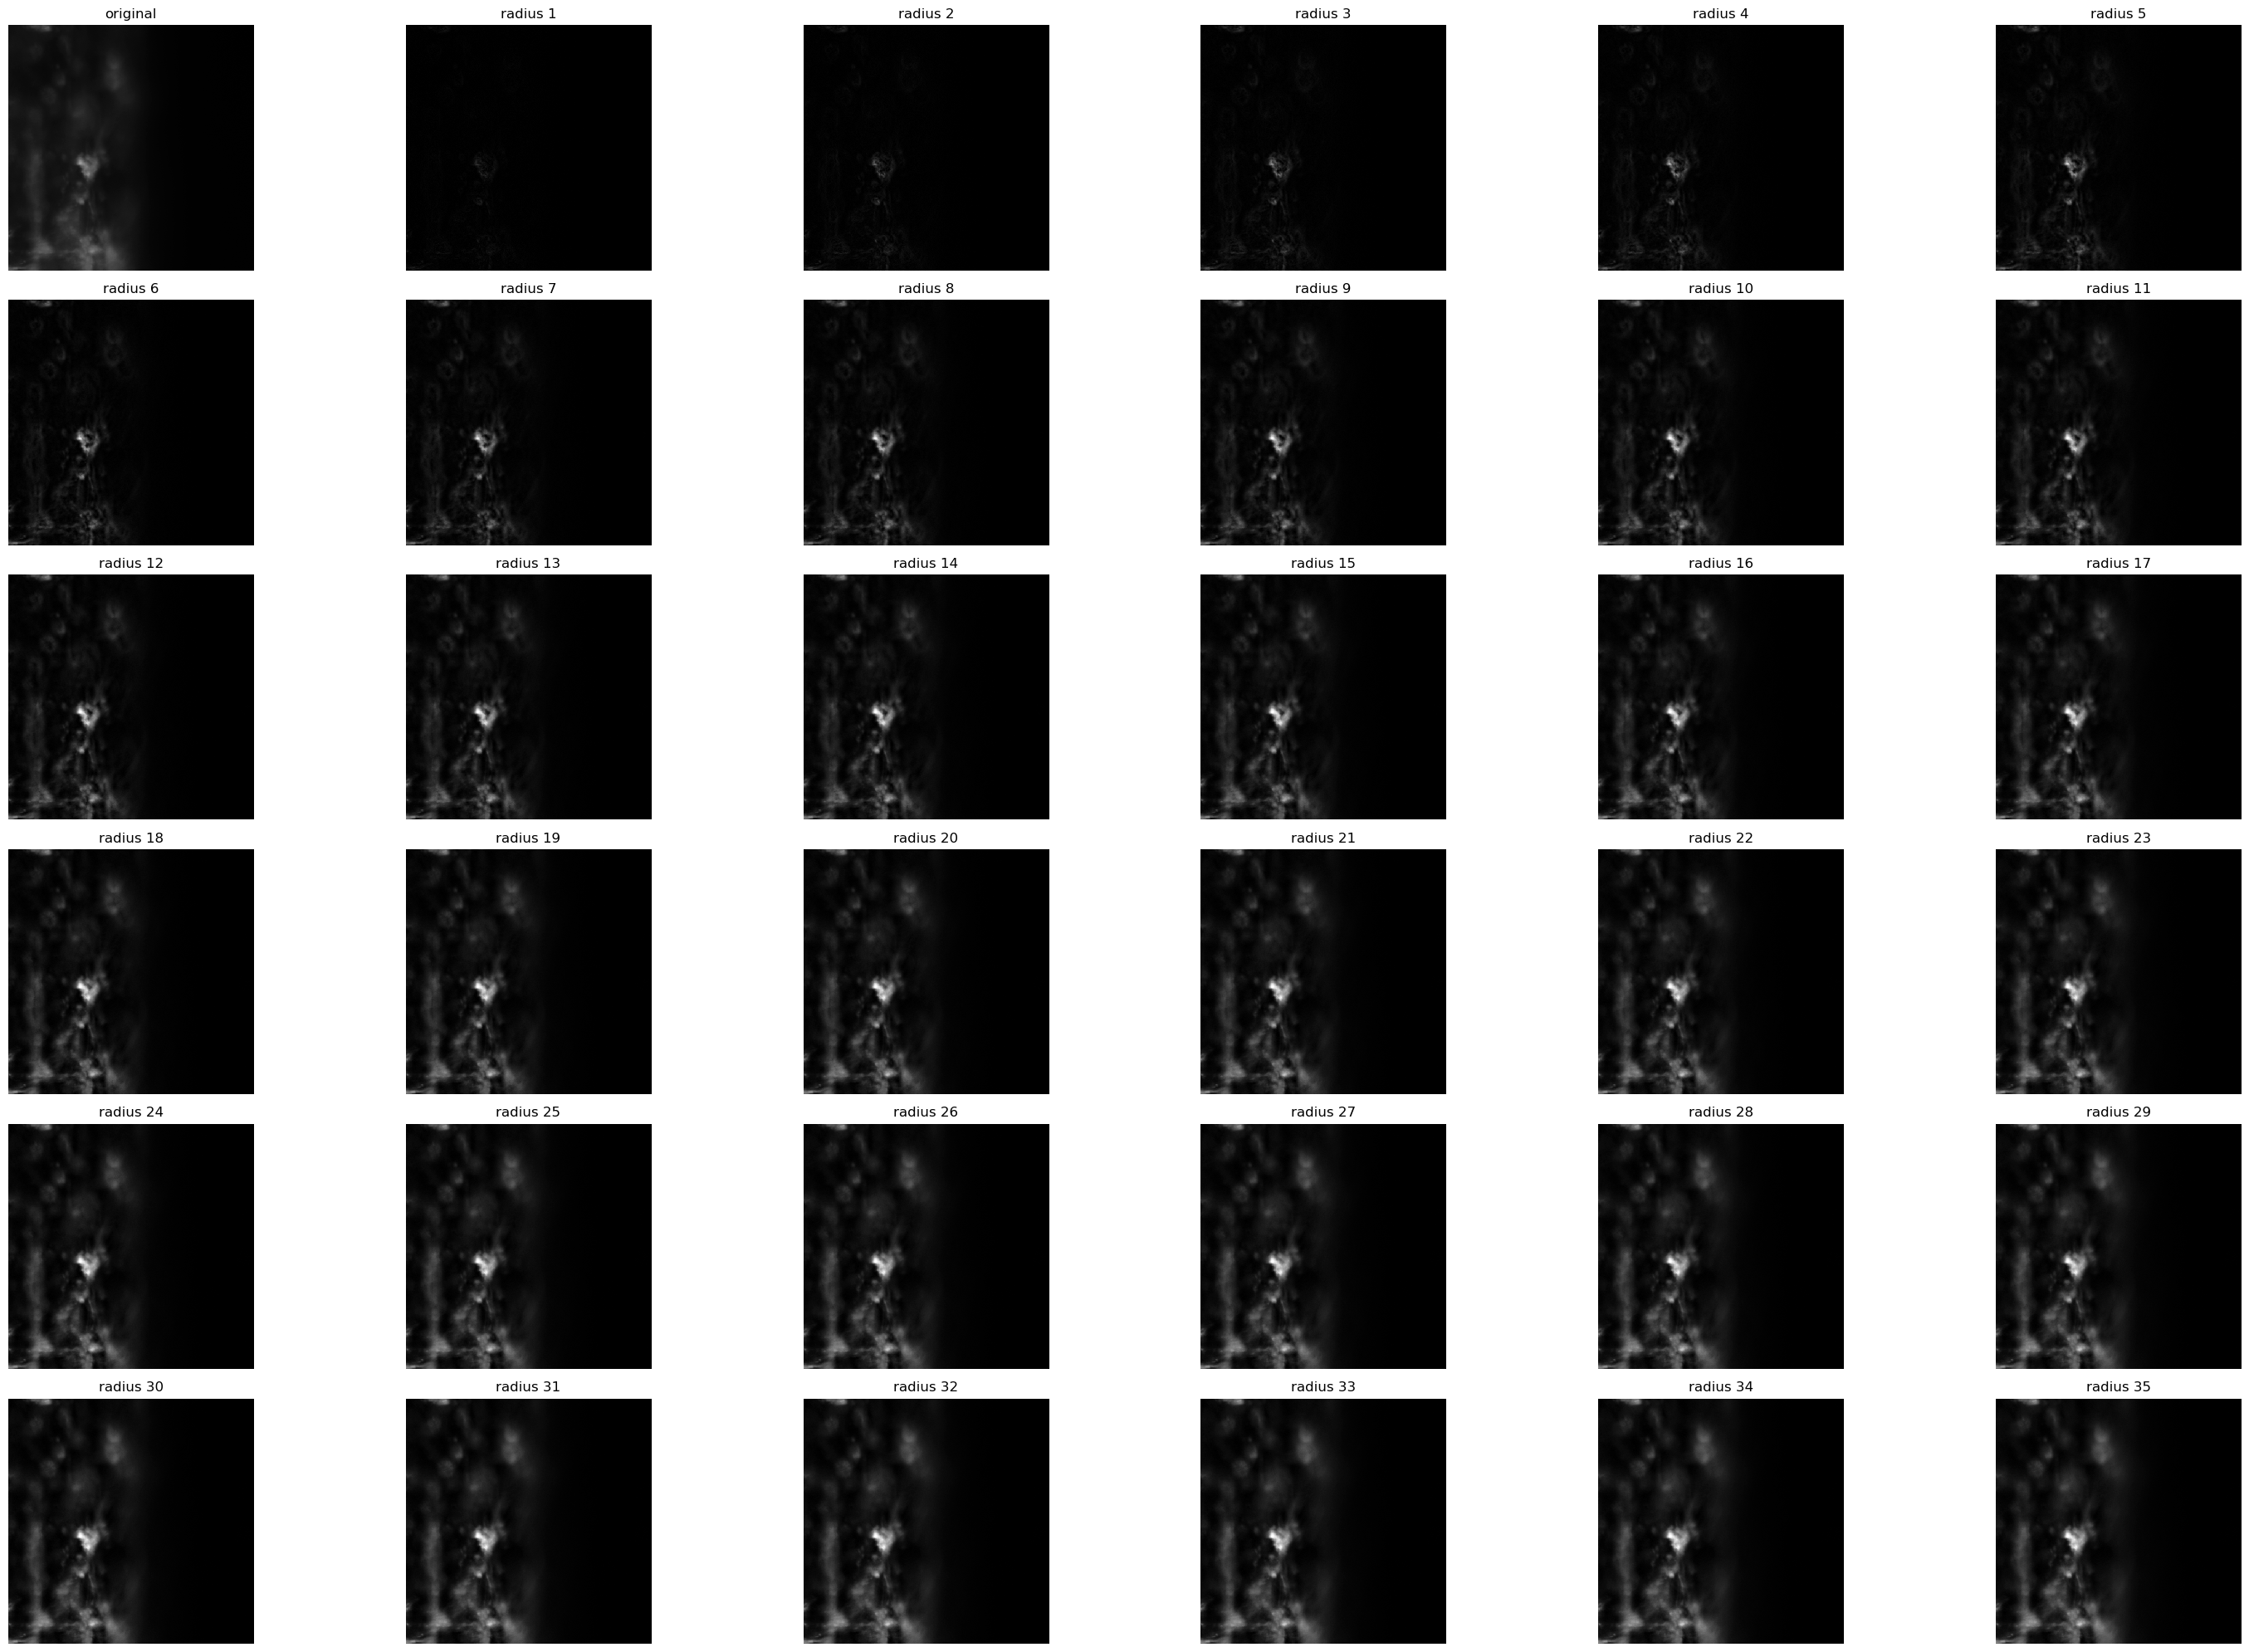

In [27]:
# 1. Calculate how many images you actually have
radii = list(range(1, 36, 1))
total_plots = len(radii) + 1 # +1 for the "original" image

# 2. Setup the figure (using 5x6 as you intended)
fig, axs = plt.subplots(6, 6, figsize=(30, 20))
axes_flat = axs.flatten() # Flattens the (5,6) array into a 1D array of 30 elements

# 3. Plot the original image on the first axis
stackview.imshow(cnx_img[10], plot=axes_flat[0], min_display_intensity=0, max_display_intensity=40000)
axes_flat[0].set_title("original")

# 4. Loop through the radii and the remaining axes
for i, radius in enumerate(radii):
    # Perform the subtraction
    background_rolling = rolling_ball(cnx_img[10], radius=radius)
    background_subtracted_rolling = cnx_img[10] - background_rolling
    
    # Use the next available axis (i + 1 because index 0 is the original)
    ax = axes_flat[i + 1]
    
    stackview.imshow(background_subtracted_rolling, plot=ax, 
                     min_display_intensity=0, max_display_intensity=18000)
    ax.set_title(f"radius {radius}")

# 5. Clean up: Hide any unused subplots (if any)
for j in range(total_plots, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()

A: Maybe 30 is the best because it didn't hole out the round structures in the top left, but also 7 preserves all the dots more 

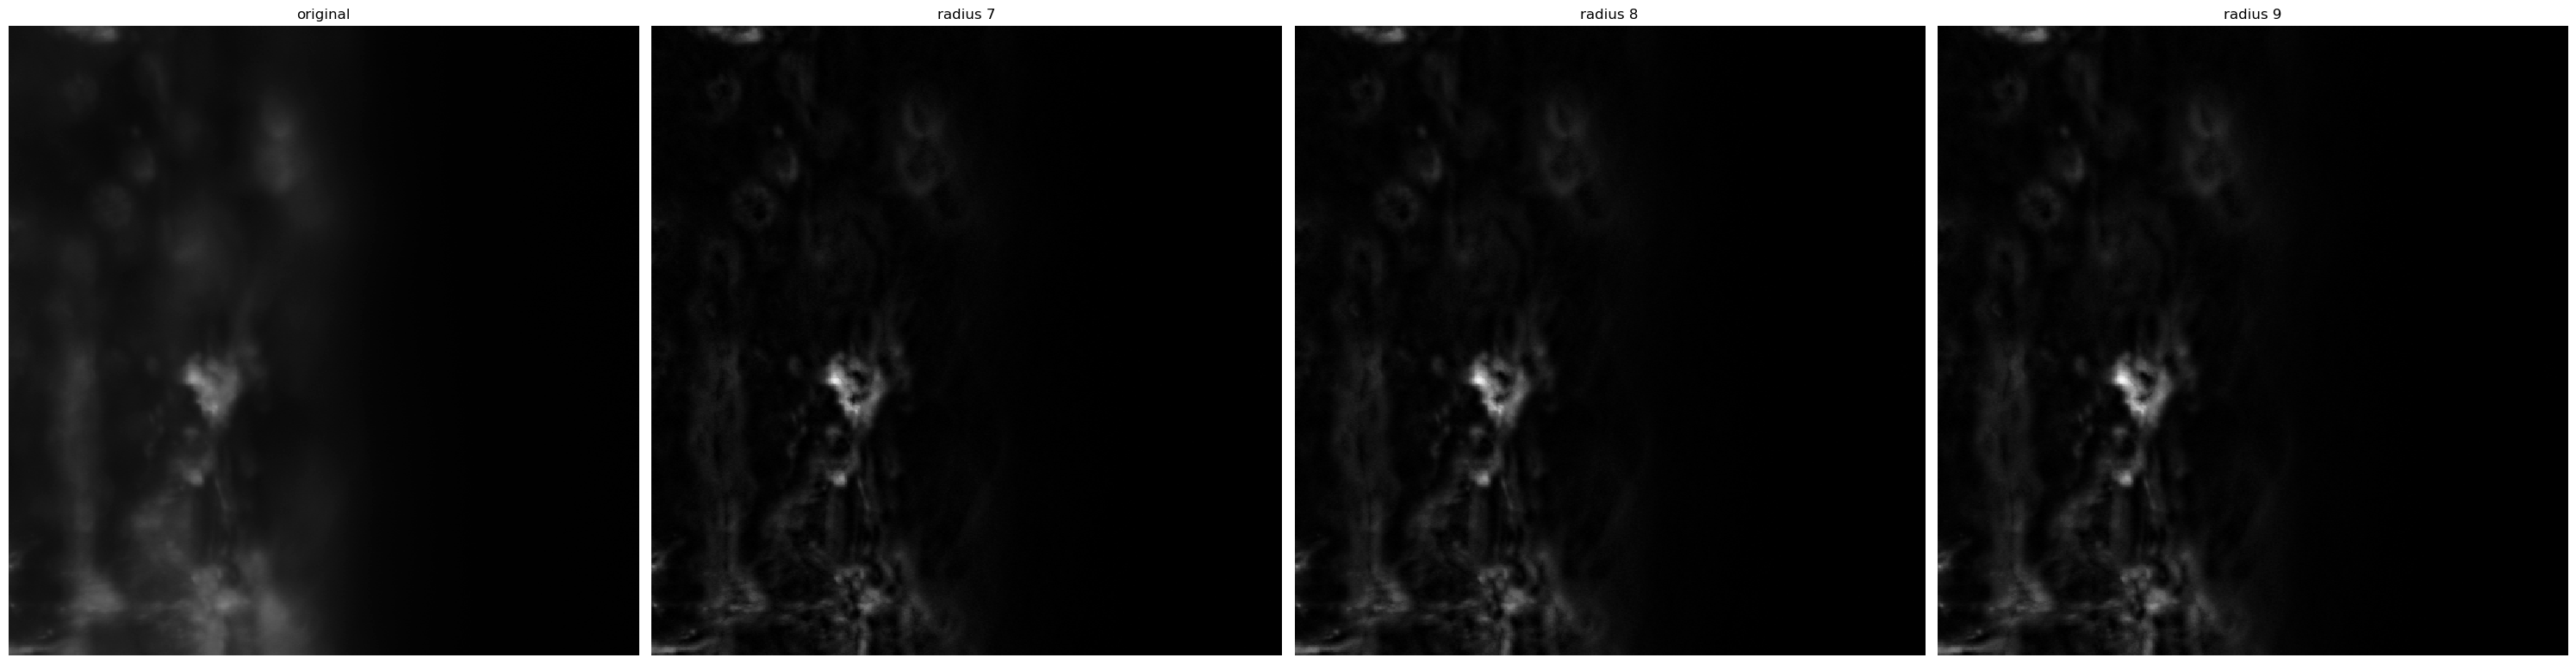

In [34]:
# 1. Calculate how many images you actually have
radii = list(range(7, 10, 1))
total_plots = len(radii) + 1 # +1 for the "original" image

# 2. Setup the figure (using 5x6 as you intended)
fig, axs = plt.subplots(1, 4, figsize=(30, 20))
axes_flat = axs.flatten() # Flattens the (5,6) array into a 1D array of 30 elements

# 3. Plot the original image on the first axis
stackview.imshow(cnx_img[10], plot=axes_flat[0], min_display_intensity=0, max_display_intensity=40000)
axes_flat[0].set_title("original")

# 4. Loop through the radii and the remaining axes
for i, radius in enumerate(radii):
    # Perform the subtraction
    background_rolling = rolling_ball(cnx_img[10], radius=radius)
    background_subtracted_rolling = cnx_img[10] - background_rolling
    
    # Use the next available axis (i + 1 because index 0 is the original)
    ax = axes_flat[i + 1]
    
    stackview.imshow(background_subtracted_rolling, plot=ax, 
                     min_display_intensity=0, max_display_intensity=18000)
    ax.set_title(f"radius {radius}")

# 5. Clean up: Hide any unused subplots (if any)
for j in range(total_plots, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()

In [28]:
# apply rolling ball background subtraction to the whole image -> takes 17 s for radius of 10
# move over planes and apply rolling ball background subtraction to each plane
background_subtracted_rolling_full = np.zeros_like(cnx_img)
for i in range(cnx_img.shape[0]):
    background_rolling = rolling_ball(cnx_img[i], radius=7)
    background_subtracted_rolling_full[i] = cnx_img[i] - background_rolling

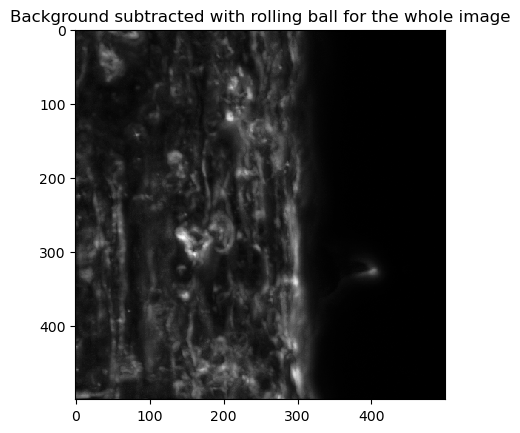

In [29]:
stackview.imshow(background_subtracted_rolling_full, axes = True, title="Background subtracted with rolling ball for the whole image")

7 looks really good so I should stick to that. I preserves the small dots really well and removes holed out structures

In [36]:
# save the full background_subtracted_rolling_full image 
io.imsave(Path(BASE_DIR/'data'/'seperate_planes'/'small_region'/f"background_subtracted_rolling_full_radius7.tiff"), background_subtracted_rolling_full)

### Go here to load full background substracted image with rolling ball

In [37]:
background_subtracted_rolling_full = io.imread(Path(BASE_DIR/'data'/'seperate_planes'/'small_region'/f"background_subtracted_rolling_full_radius7.tiff"))

In [ ]:
deconvolved = richardson_lucy_deconvolution(background_subtracted_rolling_full, psf_padded[:], 8) # 1 min per iteration for the whole image, 5 iterations would be 5 min per image

In [42]:
# save the background substracted + deconvolved image
# io.imsave(Path(BASE_DIR/'data'/'seperate_planes'/'small_region'/f"background_subtracted_rolling_full_radius7_deconvolved_8iter.tiff"), deconvolved)

# load background substracted + deconvolved image
# deconvolved = io.imread(Path(BASE_DIR/'data'/'seperate_planes'/'small_region'/f"background_subtracted_rolling_full_radius7_deconvolved_8iter.tiff"))

huygens_image = io.imread(Path(BASE_DIR/'data'/f"test_plane_254.tiff"))

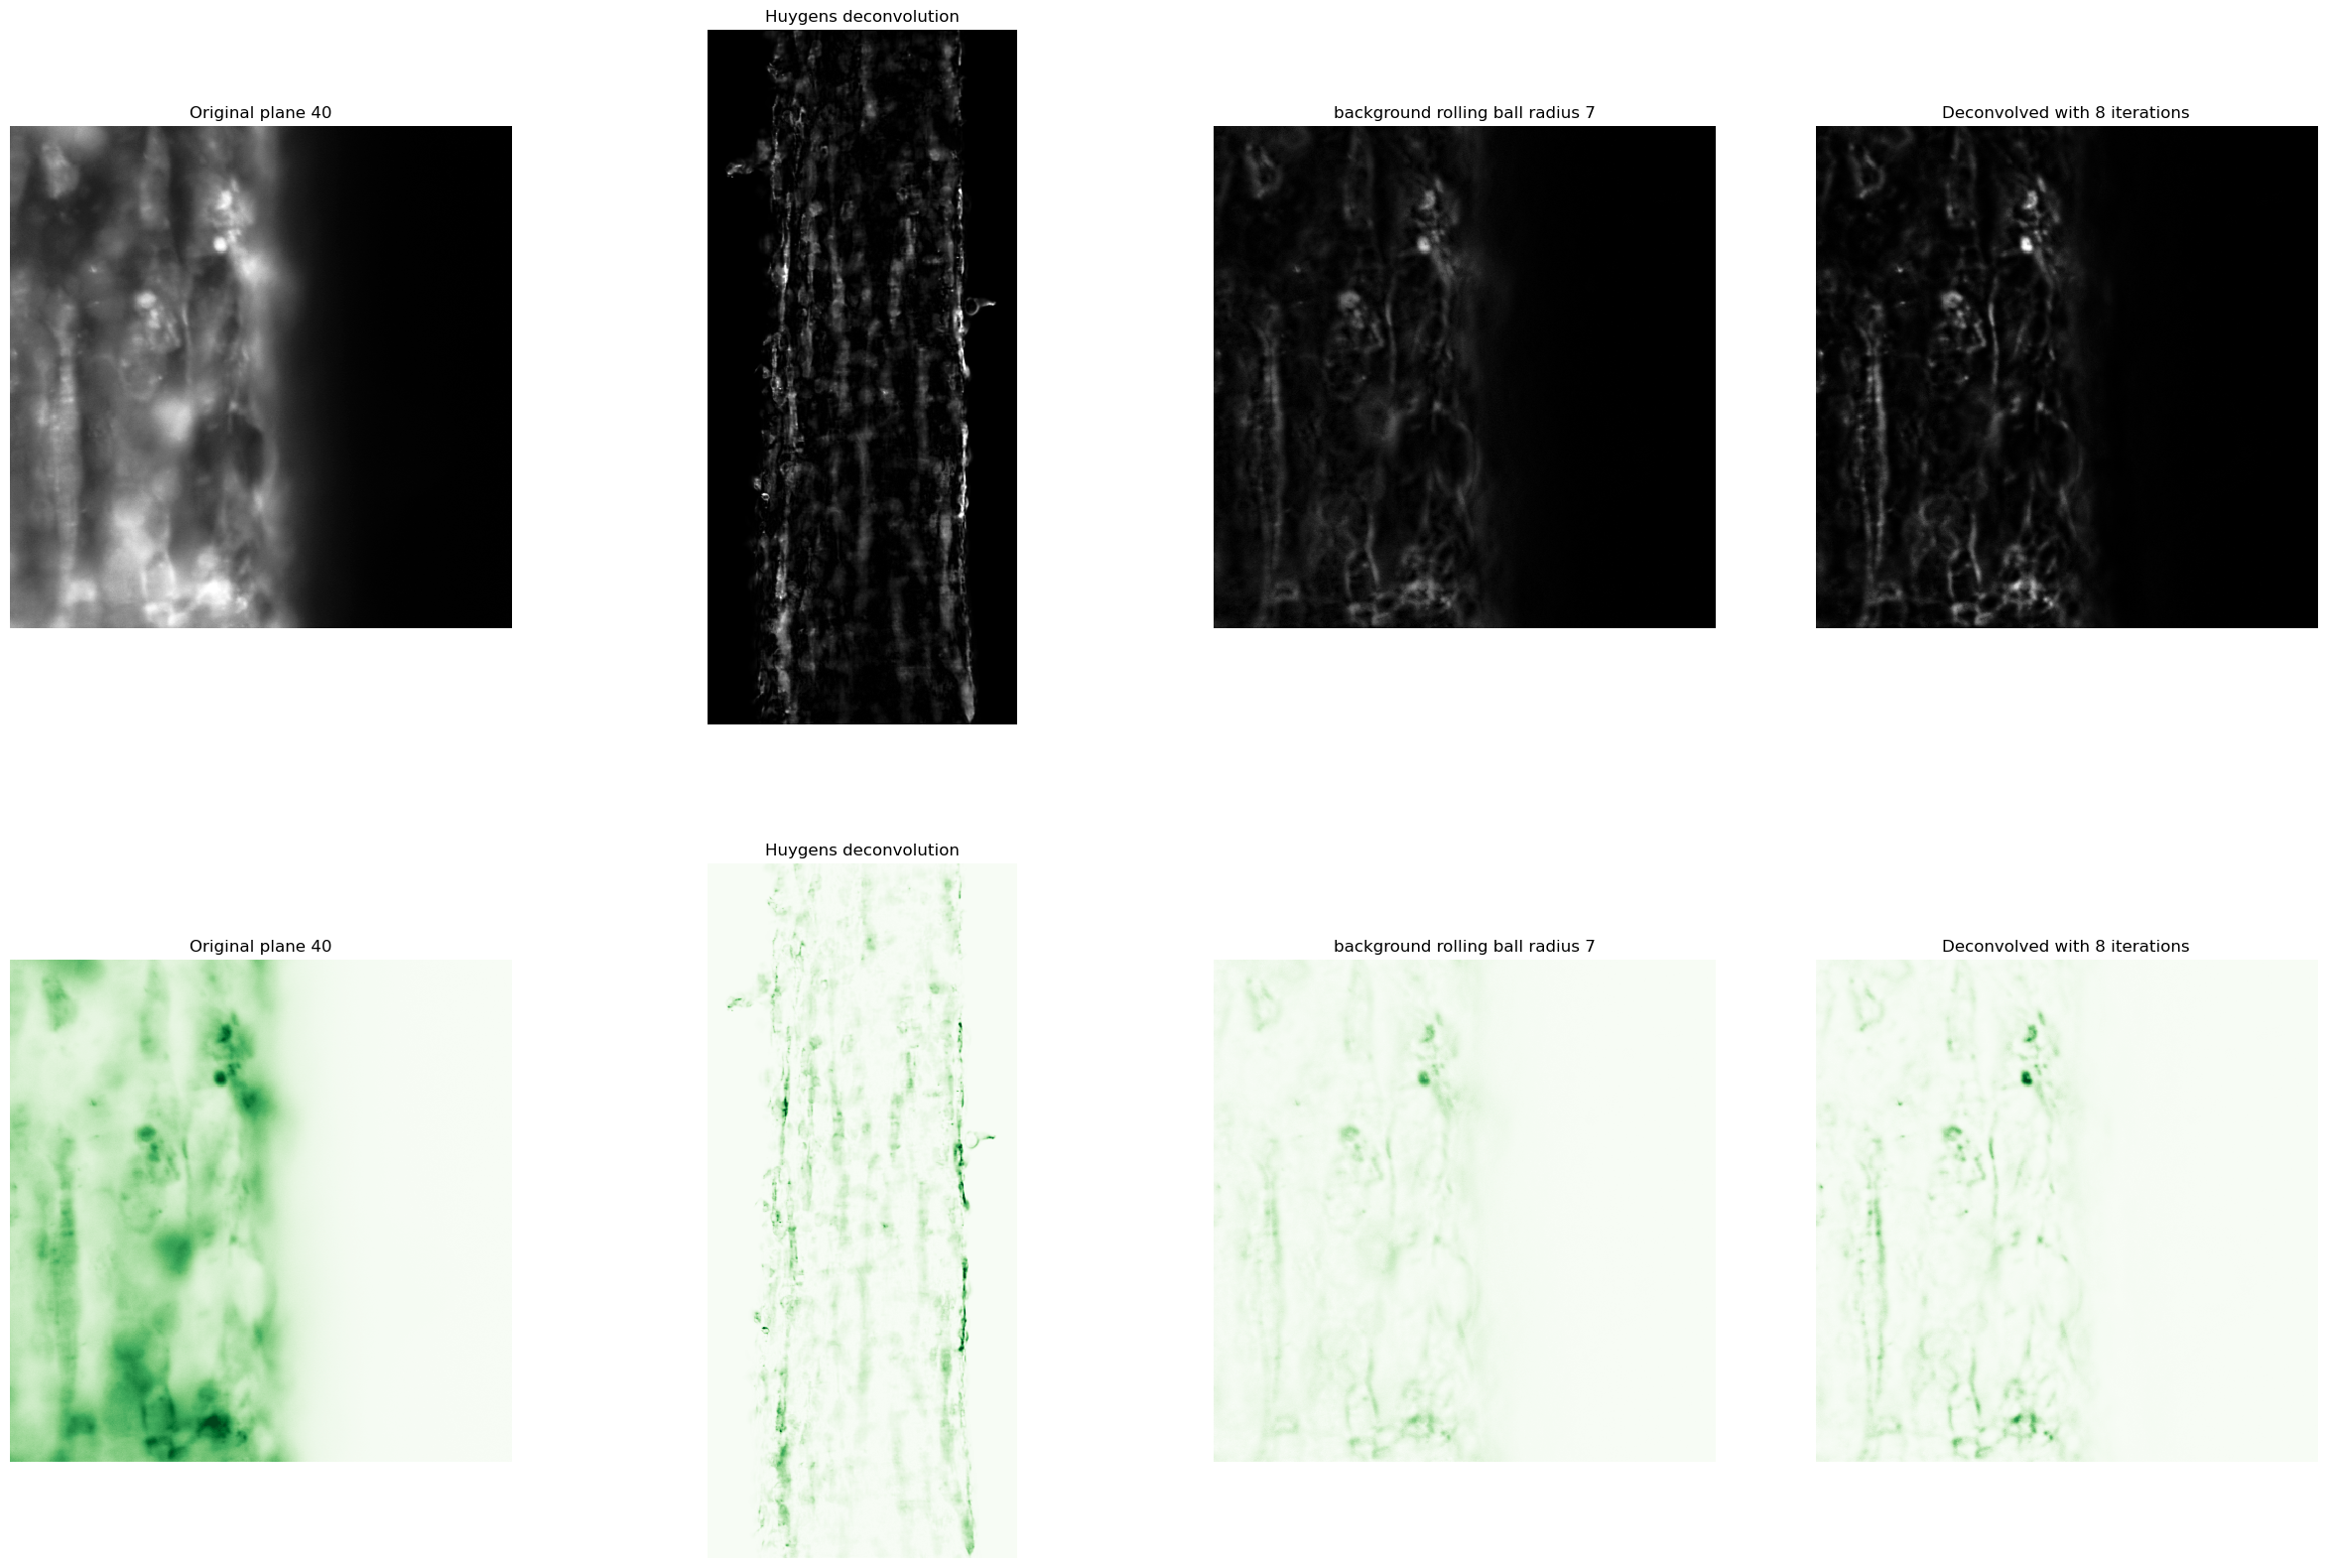

In [48]:
fig, axs = plt.subplots(2, 4, figsize=(30,20))
plane = 40
radius = 7
iterations = 8

stackview.imshow(cnx_img[plane], plot=axs[0, 0], title = "Original plane "f"{plane}", max_display_intensity=18000)
stackview.imshow(huygens_image, plot=axs[0, 1], title = "Huygens deconvolution", max_display_intensity=18000)
stackview.imshow(background_subtracted_rolling_full[plane],plot = axs[0, 2], title = f"background rolling ball radius {radius}", max_display_intensity=18000)
stackview.imshow(deconvolved[plane] , plot = axs[0, 3], title=f"Deconvolved with {iterations} iterations", max_display_intensity=18000)

stackview.imshow(cnx_img[plane], plot=axs[1, 0], title = "Original plane "f"{plane}", colormap="Greens", max_display_intensity=18000)
stackview.imshow(huygens_image, plot=axs[1, 1], title = "Huygens deconvolution", colormap="Greens", max_display_intensity=18000)
stackview.imshow(background_subtracted_rolling_full[plane],plot = axs[1, 2], title = f"background rolling ball radius {radius}",colormap="Greens", max_display_intensity=18000)
stackview.imshow(deconvolved[plane] , plot = axs[1, 3], title=f"Deconvolved with {iterations} iterations",colormap="Greens", max_display_intensity=18000)

Analysis: The images seem to lock worse after the deconvolution ? -> maybe also do the post processing step, Huygens Method and computational RL 

### Storing the deconvolved image 

In [ ]:
# apply PSF
number_of_iterations = 80
deconvolved = richardson_lucy_deconvolution(cnx_img, psf_padded, number_of_iterations)

In [ ]:
# # storing image after 40 iterations
# out_path = Path(BASE_DIR/'data/seperate_planes/small_region/cnx_254_(500, 1000)_deconvolved_80iterations.tiff')
# io.imsave(out_path, deconvolved) # save plane to folder 

### 2. Light Denoising (TBD)
Testing Image Denoising Function from bm3d python package (block matching and 3D filtering)
https://webpages.tuni.fi/foi/GCF-BM3D/index.html

Works like: 
1. find similar patches (background, structure) and stack them together into small 3D block (increase signal, decrease noise)
2. 3D Transformation where similar Patches stay and random noise vanishes (like 3D Fourier Transformation)
3. Undo 3D Transformation = now filtered version of patches in the group 
4. Putting patches back into their position (but patches are overlapping)
5. Aggregation (mean)
6. Now the softer Wiener Filtering happens (determines how big varianz of the signal is compared to variance of the noise: Signal / (Signal + Noise))

-> test different sigmas

In [35]:
import numpy as np 
from bm3d import bm3d
from PIL import Image
import matplotlib.pyplot as plt

# imagename = 'test_plane_254.tiff'

number_colors = 65535.0

y = np.array(deconvolved, dtype=np.float32) / number_colors

# estimate sigma (important!) / Do I neet to use Gaussion or Poison Distribution here ? 
sigma = 0.01   # example, must be adapted

y_denoised = bm3d(y, sigma)



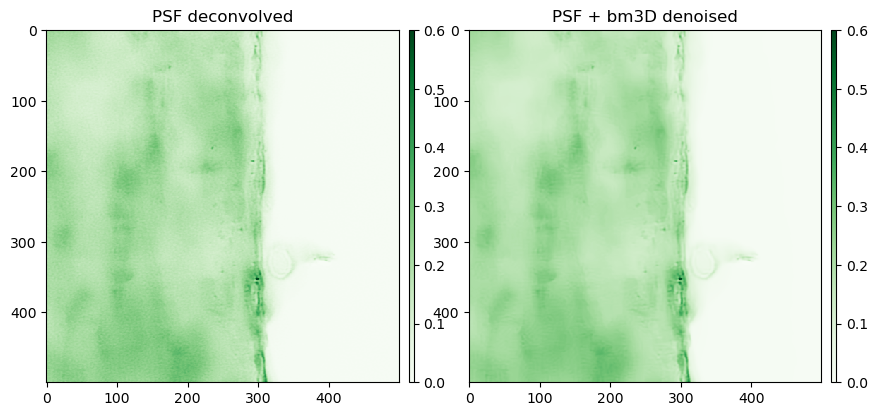

In [52]:
fig, axs = plt.subplots(1,2,figsize=(10,5))
stackview.imshow(y, plot=axs[0], title = "PSF deconvolved", axes = True, colorbar = True, colormap='Greens', min_display_intensity=0, max_display_intensity=0.6)
stackview.imshow(y_denoised, plot=axs[1], title = "PSF + bm3D denoised", axes = True, colorbar = True, colormap='Greens', min_display_intensity=0, max_display_intensity=0.6)

#### Visualizing what the algorithm removed

In [53]:
pure_noise_image = y - y_denoised

In [54]:
# round negative values to 0 
pure_noise_image[pure_noise_image < 0] = 0

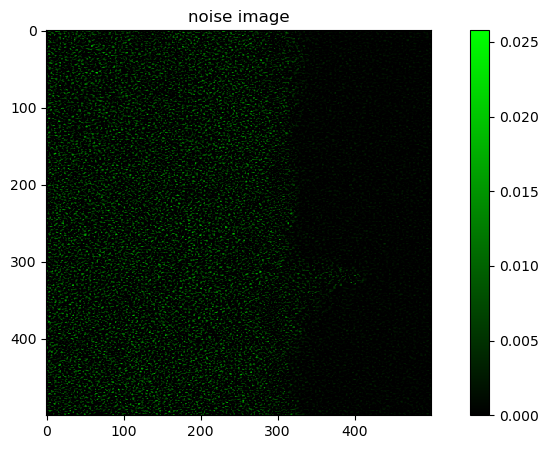

In [55]:
plt.figure(figsize=(10,5))
stackview.imshow(pure_noise_image, title = "noise image", axes = True, colorbar = True, colormap='pure_green')

### 3. Background Correction (TBD)

-> test different radius ??

In [56]:
# background substraction using rolling ball method
from skimage.restoration import rolling_ball 

In [57]:
background_rolling = rolling_ball(y_denoised, radius=30) #radius is the region looked at when determining what is background. It should be bigger than a connexin plaque so 30-50px

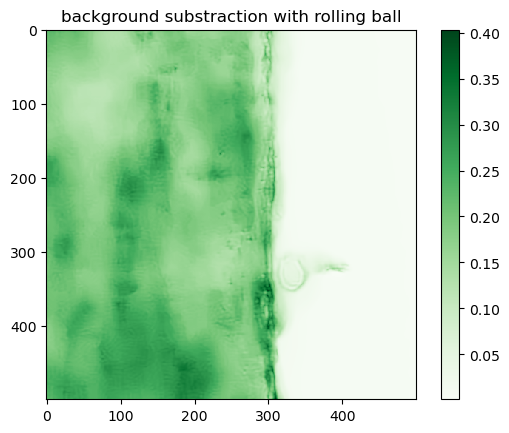

In [58]:
stackview.imshow(background_rolling, title = "background substraction with rolling ball", axes = True, colorbar = True, colormap='Greens')

### Final Image Improvement

In [62]:
hyggens_image= io.imread(Path(BASE_DIR/'data/test_plane_254.tiff'))

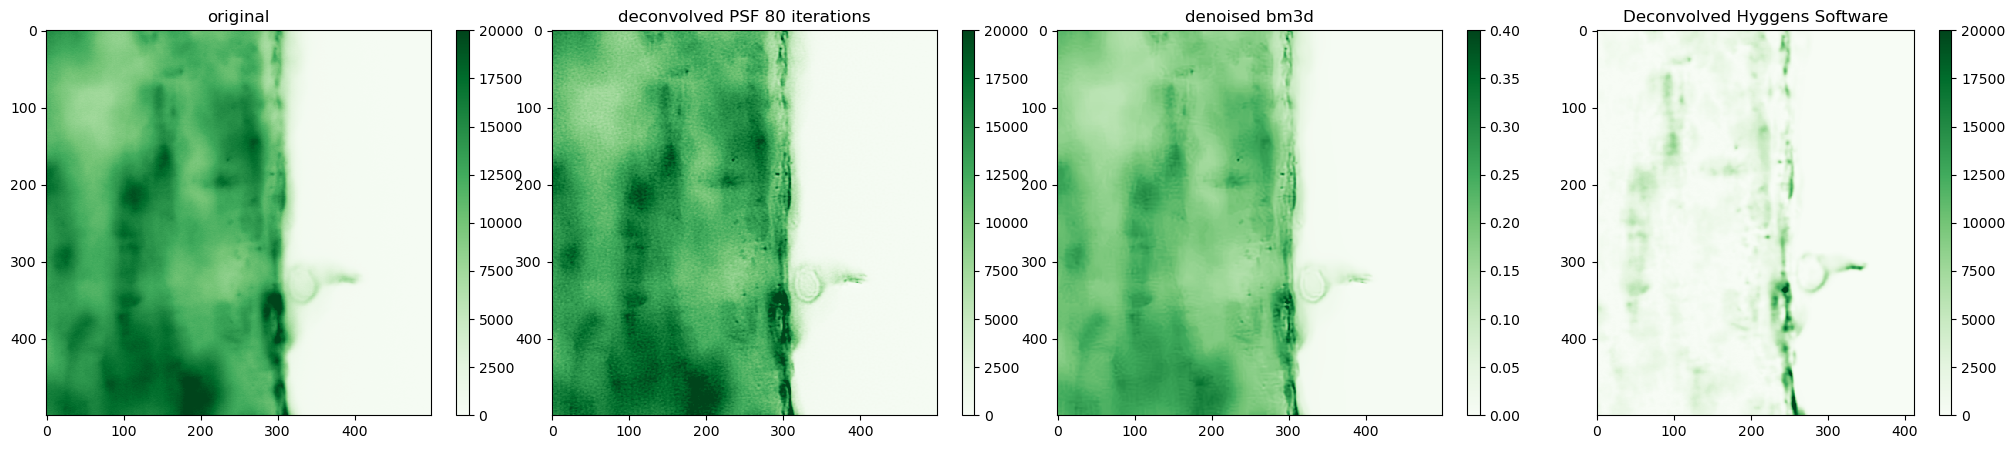

In [88]:
# compare to original image
fig, axs = plt.subplots(1, 4, figsize=(25,5))

stackview.imshow(cnx_img, plot=axs[0], title='original', axes = True, colorbar=True, colormap="Greens", min_display_intensity=0, max_display_intensity=20000)
stackview.imshow(deconvolved, plot=axs[1], title='deconvolved PSF 80 iterations', axes=True, colorbar = True, colormap="Greens", min_display_intensity=0, max_display_intensity=20000)
stackview.imshow(y_denoised, plot=axs[2], title='denoised bm3d', axes=True, colorbar = True, colormap="Greens", min_display_intensity=0, max_display_intensity=0.4)
# stackview.imshow(background_rolling, plot=axs[3], title='convolved, deblurred, background substracted', axes=True, colorbar = True, colormap="Greens")
stackview.imshow(hyggens_image[y_1:y_2, x_1:x_2], plot=axs[3], title='Deconvolved Hyggens Software', axes = True, colorbar=True, colormap="Greens", min_display_intensity=0, max_display_intensity=20000)


## 4. Segmentation

In [3]:
# load deconvolved image
cnx_img_decnv = io.imread(Path(BASE_DIR/'images/seperate_planes/small_region/cnx_254_(500, 1000)_deconvolved_40iterations.tiff'))

In [30]:
stackview.histogram(cnx_img_decnv, display_max=10000)

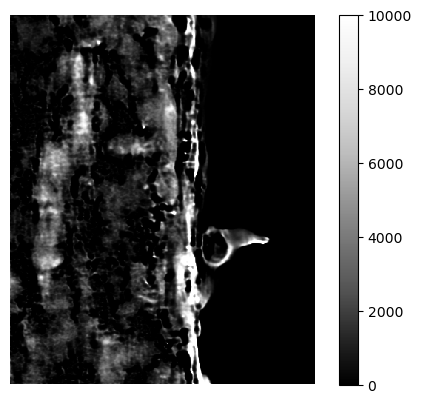

In [26]:
stackview.imshow(cnx_img_decnv, colorbar=True, max_display_intensity=10000)

#### image thresholding
https://haesleinhuepf.github.io/BioImageAnalysisNotebooks/20_image_segmentation/binarization.html


In [22]:
image_binary = cnx_img_decnv > 2000

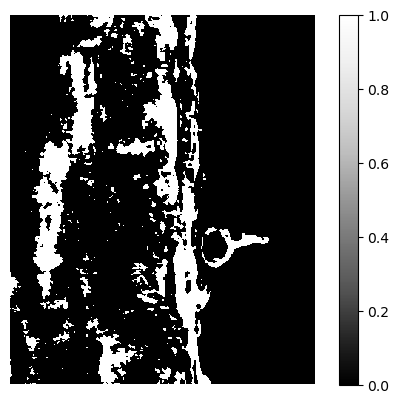

In [27]:
stackview.imshow(image_binary, colorbar=True)

In [43]:
total_pixel = np.sum(cnx_img_decnv)
non_black_pixel = np.sum(cnx_img_decnv != 0)
ratio = non_black_pixel / total_pixel

In [44]:
print("total amount pixel: ", total_pixel)
print("non black pixel: ", non_black_pixel)
print("ratio of non black pixel: ", ratio)

total amount pixel:  200313259.43436134
non black pixel:  137387
ratio of non black pixel:  0.0006858607382654017
